# SVM & Cross-Validation

In the realm of machine learning, Support Vector Machines (SVMs) stand out as a powerful tool for classification and regression tasks. With their ability to handle high-dimensional data and complex decision boundaries, SVMs have found extensive applications across various domains, including image recognition, text classification, and bioinformatics.

Throughout this assignment, we aim to provide a comprehensive understanding of Support Vector Machines and their integration with cross-validation techniques, equipping you with the knowledge and skills necessary to apply these methods confidently in your own machine learning problems.


In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV


from scipy.stats import randint 
from scipy.stats import uniform
from skimage.io import imread, imshow

pd.set_option('display.max_rows',1000)
pd.set_option('display.max_columns',1000)

## 1. Cancer detection


Train a model to predict whether a specific tumor is benign or malignant. Use the dataset 'cancer.csv' for this purpose.

Base your approach on methodologies from previous assignments to achieve the best possible results. Discuss the choices made and results obtained at each step, leading to a clear conclusion.

Tip: A classifier can only be trained with numerical values. Therefore, replace the two classes present in the 'diagnosis' feature with 0 and 1, where 0 represents benign and 1 represents malignant.




In [3]:
# Reading the dataset

dataset = pd.read_csv('cancer.csv')
dataset.head(10)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.013080,0.01860,0.013400,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.040060,0.03832,0.020580,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.074580,0.05661,0.018670,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.024610,0.05688,0.018850,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,0.3345,0.8902,2.217,27.19,0.007510,0.033450,0.03672,0.011370,0.02165,0.005082,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440
5,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,0.4467,0.7732,3.180,53.91,0.004314,0.013820,0.02254,0.010390,0.01369,0.002179,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368
6,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,0.5835,1.3770,3.856,50.96,0.008805,0.030290,0.02488,0.014480,0.01486,0.005412,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510
7,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,0.3063,1.0020,2.406,24.32,0.005731,0.035020,0.03553,0.012260,0.02143,0.003749,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720
8,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,0.2976,1.5990,2.039,23.94,0.007149,0.072170,0.07743,0.014320,0.01789,0.010080,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750
9,845636,M,16.02,23.24,102.70,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,0.3795,1.1870,2.466,40.51,0.004029,0.009269,0.01101,0.007591,0.01460,0.003042,19.19,33.88,123.80,1150.0,0.1181,0.1551,0.1459,0.09975,0.2948,0.08452


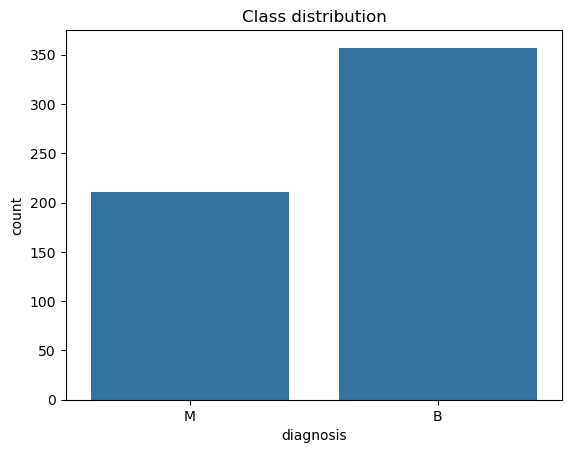

diagnosis
B    0.628521
M    0.371479
Name: proportion, dtype: float64


In [4]:
# Check whether or not the dataset is imbalanced
sns.countplot(x='diagnosis', data=dataset)
plt.title("Class distribution")
plt.show()

print(dataset['diagnosis'].value_counts(normalize=True))

In [5]:
# Drop the ID column
dataset = dataset.drop(columns=['id'])


# Replace B by 0 and M by 1 in the diagnosis column
dataset['diagnosis'] = dataset['diagnosis'].map({'B': 0, 'M': 1})


# Split into features and targets
X = dataset.drop(columns=['diagnosis'])
y = dataset['diagnosis']


# Split into training set and test set. Make sure that 150 samples end up in the test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=150, random_state=13)


# To avoid a conversion warning during scaling:
X_train = X_train.astype('float64')
X_test = X_test.astype('float64')


# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Test a bas model
model = LogisticRegression(C=1, max_iter=5000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nBalanced Accuracy Score:", balanced_accuracy_score(y_test, y_pred))
print("\nF1 Score:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9733333333333334

Confusion Matrix:
 [[93  1]
 [ 3 53]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        94
           1       0.98      0.95      0.96        56

    accuracy                           0.97       150
   macro avg       0.98      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



Train a logistic regression model via cross-validation.

Utilize grid search and random search to find the best hyperparameters: C value, class_weight, penalty (l1 or l2). More information: http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html.

Vary the value of K in K-fold cross-validation. Discuss the results.
Test the obtained models on the test set. Which search technique do you prefer and why?

Does it make sense to expand the feature set with polynomial features? Test this. Polynomial Features: http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html


In [8]:
# Cross-validation via grid search
log_reg = LogisticRegression(max_iter=5000, solver='liblinear')

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("\nBest CV score:", grid_search.best_score_)

Best parameters: {'C': 1, 'class_weight': None, 'penalty': 'l2'}

Best CV score: 0.9808663224325874


### Conclusion after Cross-validation via grid search

...

In [10]:
# Cross-validation via random search
param_dist = {
    'C': np.logspace(-3, 3, 100),
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    random_state=13,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("\nBest CV score:", random_search.best_score_)

Best parameters: {'penalty': 'l2', 'class_weight': None, 'C': np.float64(0.3511191734215131)}

Best CV score: 0.9808663224325876


### Conclusion after Cross-validation via random search

...

Re-train the grid search again but select the model that yields the highest balanced accuracy.
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html#sklearn.metrics.balanced_accuracy_score
Also check http://mvpa.blogspot.com/2015/12/balanced-accuracy-what-and-why.html

Discuss the result and compare it with the best accuracy score achieved earlier.

In [11]:
# Cross-validation 
grid_balanced = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_balanced.fit(X_train, y_train)

print("Best params:", grid_balanced.best_params_)
print("\nBest balanced accuracy:", grid_balanced.best_score_)

Best params: {'C': 1, 'class_weight': None, 'penalty': 'l2'}

Best balanced accuracy: 0.9768715763846622


### Conclusion after re-train for highest balanced accuracy

...

Search for the model that yields the highest F1-score. To do this, you should utilize the F1 micro score.
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score

In [12]:
# Cross-validation 
grid_f1 = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='f1_micro',
    n_jobs=-1
)

grid_f1.fit(X_train, y_train)

print("Best params:", grid_f1.best_params_)
print("\nBest F1 score:", grid_f1.best_score_)

Best params: {'C': 1, 'class_weight': None, 'penalty': 'l2'}

Best F1 score: 0.9808663224325874


### Conclusion after searching for the highest F1_score

...

Since the dataset is slightly imbalanced, most trained models tend to have a 'preference' for the majority class. Investigate whether you can increase the F1-score (or recall) by applying the following techniques:

Passing the parameter class_weight='balanced' to the models.
Performing oversampling using SMOTE. More information: https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html. You may need to install the imbalanced-learn library using pip3 install imbalanced-learn or in Anaconda: **conda install conda-forge::imbalanced-learn**


Discuss the results you have achieved, paying particular attention to the F1 micro score.

In [13]:
# Balancing 
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=13)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_smote))

Before SMOTE: [263 155]
After SMOTE: [263 263]


In [16]:
# Oversampling with SMOTE
log_reg_balanced = LogisticRegression(
    max_iter=5000,
    solver='liblinear',
    class_weight='balanced'
)

log_reg_balanced.fit(X_train_smote, y_train_smote)

y_pred = log_reg_balanced.predict(X_test)

print("\nBalanced Accuracy Score:", balanced_accuracy_score(y_test, y_pred))
print("\nF1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Balanced Accuracy Score: 0.9821428571428572

F1 Score: 0.9818181818181818

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        94
           1       1.00      0.96      0.98        56

    accuracy                           0.99       150
   macro avg       0.99      0.98      0.99       150
weighted avg       0.99      0.99      0.99       150



### Conclusion after balancing with SMOTE

...

Suppose there is a demand to reduce the number of false negatives to 0. A false negative means that the diagnosis is benign while the tumor is actually malignant.


Your options are to apply classweight balancing or threshold moving.


Threshold moving, in the context of binary classification models like logistic regression or support vector machines, refers to adjusting the threshold value used to make predictions.

By default, these models classify instances into one of two classes based on whether the predicted probability (output of the model) exceeds a certain threshold. For instance, if the threshold is set to 0.5, any instance with a predicted probability greater than 0.5 is classified as positive, while instances with predicted probabilities less than or equal to 0.5 are classified as negative.

Threshold moving involves changing this threshold value to optimize specific metrics like accuracy, precision, recall, or F1-score. For example, if reducing false negatives is critical (e.g., in medical diagnosis where missing a positive case could be harmful), one might lower the threshold to ensure more instances are classified as positive, thus potentially reducing false negatives.



Which threshold should be set to ensure that the model predicts no false negatives on the test set while still maintaining the highest possible accuracy? Plot the number of false negatives as a function of the threshold. Discuss the results.

In [17]:
# Reducing the number of false negatives
y_pred_proba = log_reg_balanced.predict_proba(X_test)

best_threshold = 0.5
best_accuracy_with_zero_fn = 0

for threshold in [0.5, 0.4, 0.3, 0.2, 0.1, 0.09, 0.08, 0.07, 0.06, 0.05]:
    y_pred_threshold = (y_pred_proba[:, 1] >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    acc = accuracy_score(y_test, y_pred_threshold)

    print(f"Threshold: {threshold:.4f}")
    print(f"True Negatives: {tn}, False Positives: {fp}")
    print(f"False Negative: {fn}, True Positives: {tp}")
    print(f"Accuracy: {acc:.4f}")

    if fn == 0 and acc > best_accuracy_with_zero_fn:
        best_threshold = threshold
        best_accuracy_with_zero_fn = acc
    print()

Threshold: 0.5000
True Negatives: 94, False Positives: 0
False Negative: 2, True Positives: 54
Accuracy: 0.9867

Threshold: 0.4000
True Negatives: 92, False Positives: 2
False Negative: 2, True Positives: 54
Accuracy: 0.9733

Threshold: 0.3000
True Negatives: 91, False Positives: 3
False Negative: 2, True Positives: 54
Accuracy: 0.9667

Threshold: 0.2000
True Negatives: 83, False Positives: 11
False Negative: 2, True Positives: 54
Accuracy: 0.9133

Threshold: 0.1000
True Negatives: 78, False Positives: 16
False Negative: 1, True Positives: 55
Accuracy: 0.8867

Threshold: 0.0900
True Negatives: 78, False Positives: 16
False Negative: 1, True Positives: 55
Accuracy: 0.8867

Threshold: 0.0800
True Negatives: 78, False Positives: 16
False Negative: 0, True Positives: 56
Accuracy: 0.8933

Threshold: 0.0700
True Negatives: 78, False Positives: 16
False Negative: 0, True Positives: 56
Accuracy: 0.8933

Threshold: 0.0600
True Negatives: 76, False Positives: 18
False Negative: 0, True Positives

### Conclusions

...

## 2 - MNIST

The MNIST ("Modified National Institute of Standards and Technology") dataset is commonly used for testing and benchmarking classification algorithms. It contains tens of thousands of images of handwritten digits. More information about this dataset can be found at: [MNIST Dataset](http://yann.lecun.com/exdb/mnist/)

For this task, three data files are provided:

1. 'train.csv' contains labeled data for training the classifier.
2. 'test.csv' contains labeled data for testing the trained classifier.
3. 'test_Kaggle.csv' contains unlabeled data for evaluating the classifier through the competition found at [Kaggle Digit Recognizer](https://www.kaggle.com/c/digit-recognizer). This data is only useful for participating in the Kaggle competition.

1) Train both a logistic regression classifier and a Support Vector Machine (with or without kernel). Tune the hyperparameters to find the most performant classifier by maximizing accuracy or minimizing the error rate on the 'test.csv' dataset. The error rate = 1 - accuracy. Training Support Vector Machines (especially those with kernel) requires significant computational resources. Therefore, it is advisable to initially train on a small portion of the training set. Training via logistic regression is less demanding on the CPU; nonetheless, it is recommended to use the lbfgs solver (LogisticRegression(multi_class='multinomial', solver='lbfgs')).

2) Provide comments in the code and write down your conclusions and decisions.

3) Is normalization necessary here? Which normalization method would you use? Is StandardScaler a good choice?

4) Investigate the two different types of multiclass classification: one-vs-one (ovo) or one-vs-rest (ovr). Focus on accuracy and computation time. What are the conclusions?

5) Test your final classifier with some self-written digits. What are the findings? What does classification accuracy depend on?

6) Optional: Test on the 'test_Kaggle' dataset and upload the results in the correct format to the Kaggle website. What score did you achieve? Compare this score with the score on [MNIST](http://yann.lecun.com/exdb/mnist/).

You can visualize a digit using 'plt.imshow(X_train[n].reshape((28, 28)),cmap = 'gray')'.

In [12]:
# Reading the dataset

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

df_train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,pixel41,pixel42,pixel43,pixel44,pixel45,pixel46,pixel47,pixel48,pixel49,pixel50,pixel51,pixel52,pixel53,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,pixel64,pixel65,pixel66,pixel67,pixel68,pixel69,pixel70,pixel71,pixel72,pixel73,pixel74,pixel75,pixel76,pixel77,pixel78,pixel79,pixel80,pixel81,pixel82,pixel83,pixel84,pixel85,pixel86,pixel87,pixel88,pixel89,pixel90,pixel91,pixel92,pixel93,pixel94,pixel95,pixel96,pixel97,pixel98,pixel99,pixel100,pixel101,pixel102,pixel103,pixel104,pixel105,pixel106,pixel107,pixel108,pixel109,pixel110,pixel111,pixel112,pixel113,pixel114,pixel115,pixel116,pixel117,pixel118,pixel119,pixel120,pixel121,pixel122,pixel123,pixel124,pixel125,pixel126,pixel127,pixel128,pixel129,pixel130,pixel131,pixel132,pixel133,pixel134,pixel135,pixel136,pixel137,pixel138,pixel139,pixel140,pixel141,pixel142,pixel143,pixel144,pixel145,pixel146,pixel147,pixel148,pixel149,pixel150,pixel151,pixel152,pixel153,pixel154,pixel155,pixel156,pixel157,pixel158,pixel159,pixel160,pixel161,pixel162,pixel163,pixel164,pixel165,pixel166,pixel167,pixel168,pixel169,pixel170,pixel171,pixel172,pixel173,pixel174,pixel175,pixel176,pixel177,pixel178,pixel179,pixel180,pixel181,pixel182,pixel183,pixel184,pixel185,pixel186,pixel187,pixel188,pixel189,pixel190,pixel191,pixel192,pixel193,pixel194,pixel195,pixel196,pixel197,pixel198,pixel199,pixel200,pixel201,pixel202,pixel203,pixel204,pixel205,pixel206,pixel207,pixel208,pixel209,pixel210,pixel211,pixel212,pixel213,pixel214,pixel215,pixel216,pixel217,pixel218,pixel219,pixel220,pixel221,pixel222,pixel223,pixel224,pixel225,pixel226,pixel227,pixel228,pixel229,pixel230,pixel231,pixel232,pixel233,pixel234,pixel235,pixel236,pixel237,pixel238,pixel239,pixel240,pixel241,pixel242,pixel243,pixel244,pixel245,pixel246,pixel247,pixel248,pixel249,pixel250,pixel251,pixel252,pixel253,pixel254,pixel255,pixel256,pixel257,pixel258,pixel259,pixel260,pixel261,pixel262,pixel263,pixel264,pixel265,pixel266,pixel267,pixel268,pixel269,pixel270,pixel271,pixel272,pixel273,pixel274,pixel275,pixel276,pixel277,pixel278,pixel279,pixel280,pixel281,pixel282,pixel283,pixel284,pixel285,pixel286,pixel287,pixel288,pixel289,pixel290,pixel291,pixel292,pixel293,pixel294,pixel295,pixel296,pixel297,pixel298,pixel299,pixel300,pixel301,pixel302,pixel303,pixel304,pixel305,pixel306,pixel307,pixel308,pixel309,pixel310,pixel311,pixel312,pixel313,pixel314,pixel315,pixel316,pixel317,pixel318,pixel319,pixel320,pixel321,pixel322,pixel323,pixel324,pixel325,pixel326,pixel327,pixel328,pixel329,pixel330,pixel331,pixel332,pixel333,pixel334,pixel335,pixel336,pixel337,pixel338,pixel339,pixel340,pixel341,pixel342,pixel343,pixel344,pixel345,pixel346,pixel347,pixel348,pixel349,pixel350,pixel351,pixel352,pixel353,pixel354,pixel355,pixel356,pixel357,pixel358,pixel359,pixel360,pixel361,pixel362,pixel363,pixel364,pixel365,pixel366,pixel367,pixel368,pixel369,pixel370,pixel371,pixel372,pixel373,pixel374,pixel375,pixel376,pixel377,pixel378,pixel379,pixel380,pixel381,pixel382,pixel383,pixel384,pixel385,pixel386,pixel387,pixel388,pixel389,pixel390,pixel391,pixel392,pixel393,pixel394,pixel395,pixel396,pixel397,pixel398,pixel399,pixel400,pixel401,pixel402,pixel403,pixel404,pixel405,pixel406,pixel407,pixel408,pixel409,pixel410,pixel411,pixel412,pixel413,pixel414,pixel415,pixel416,pixel417,pixel418,pixel419,pixel420,pixel421,pixel422,pixel423,pixel424,pixel425,pixel426,pixel427,pixel428,pixel429,pixel430,pixel431,pixel432,pixel433,pixel434,pixel435,pixel436,pixel437,pixel438,pixel439,pixel440,pixel441,pixel442,pixel443,pixel444,pixel445,pixel446,pixel447,pixel448,pixel449,pixel450,pixel451,pixel452,pixel453,pixel454,pixel455

In [5]:
##### Classificatie van MNIST

# Split into features and targets



# Convert to numpy arrays
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)
X_train = np.asarray(X_train)
X_test = np.asarray(X_test)

# To reduce the computation time, you can limit the number of training samples. For example to 2000 digits.


training_size = 2000

X_train = X_train[0:training_size,:]
y_train = y_train[0:training_size]


# Scaling

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

In [15]:
# Training and testing a logistic regression model



In [16]:
# Training and testing an SVM model. Be aware that this can take a lot of time to compute



In [ ]:
# Check the computation time and compare between one-vs-one and one-vs-rest classification

import time

# one-vs-one
start = time.clock()



stop = time.clock()

print('computation time one-vs-one: ',stop-start)


# one-vs-rest

start = time.clock()

model = SVC(decision_function_shape='ovr')


stop = time.clock()

print('computation time one-vs-rest: ',stop-start)

In [ ]:
# Classifify your own handwritten digit


from skimage.io import imread, imshow
from skimage.transform import resize

testimage = imread("./testimage.jpg", as_gray = True)

# The image might already be scaled between 0 and 1, so extra scaling is not necessary anymore

# Show the test image:
imshow(testimage)


# reshape the test image from a 2D array into a 1D vector

testimage = testimage.reshape(1,-1)
print(X_train[1].shape)

# classify the image


# what is the confidence of the model?